In [36]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding
Thesis plot settings applied


In [37]:

h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
vels = h5file['3D0']['U100']['L100']['RPM12']

u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()

u, v = oj.scaleVel(u, v, 60)
u, v = u*25, v*25
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

Time = oj.frames_to_seconds(u, v, 60)
vort, vort_gauss = oj.calculate_vorticity(u, v)

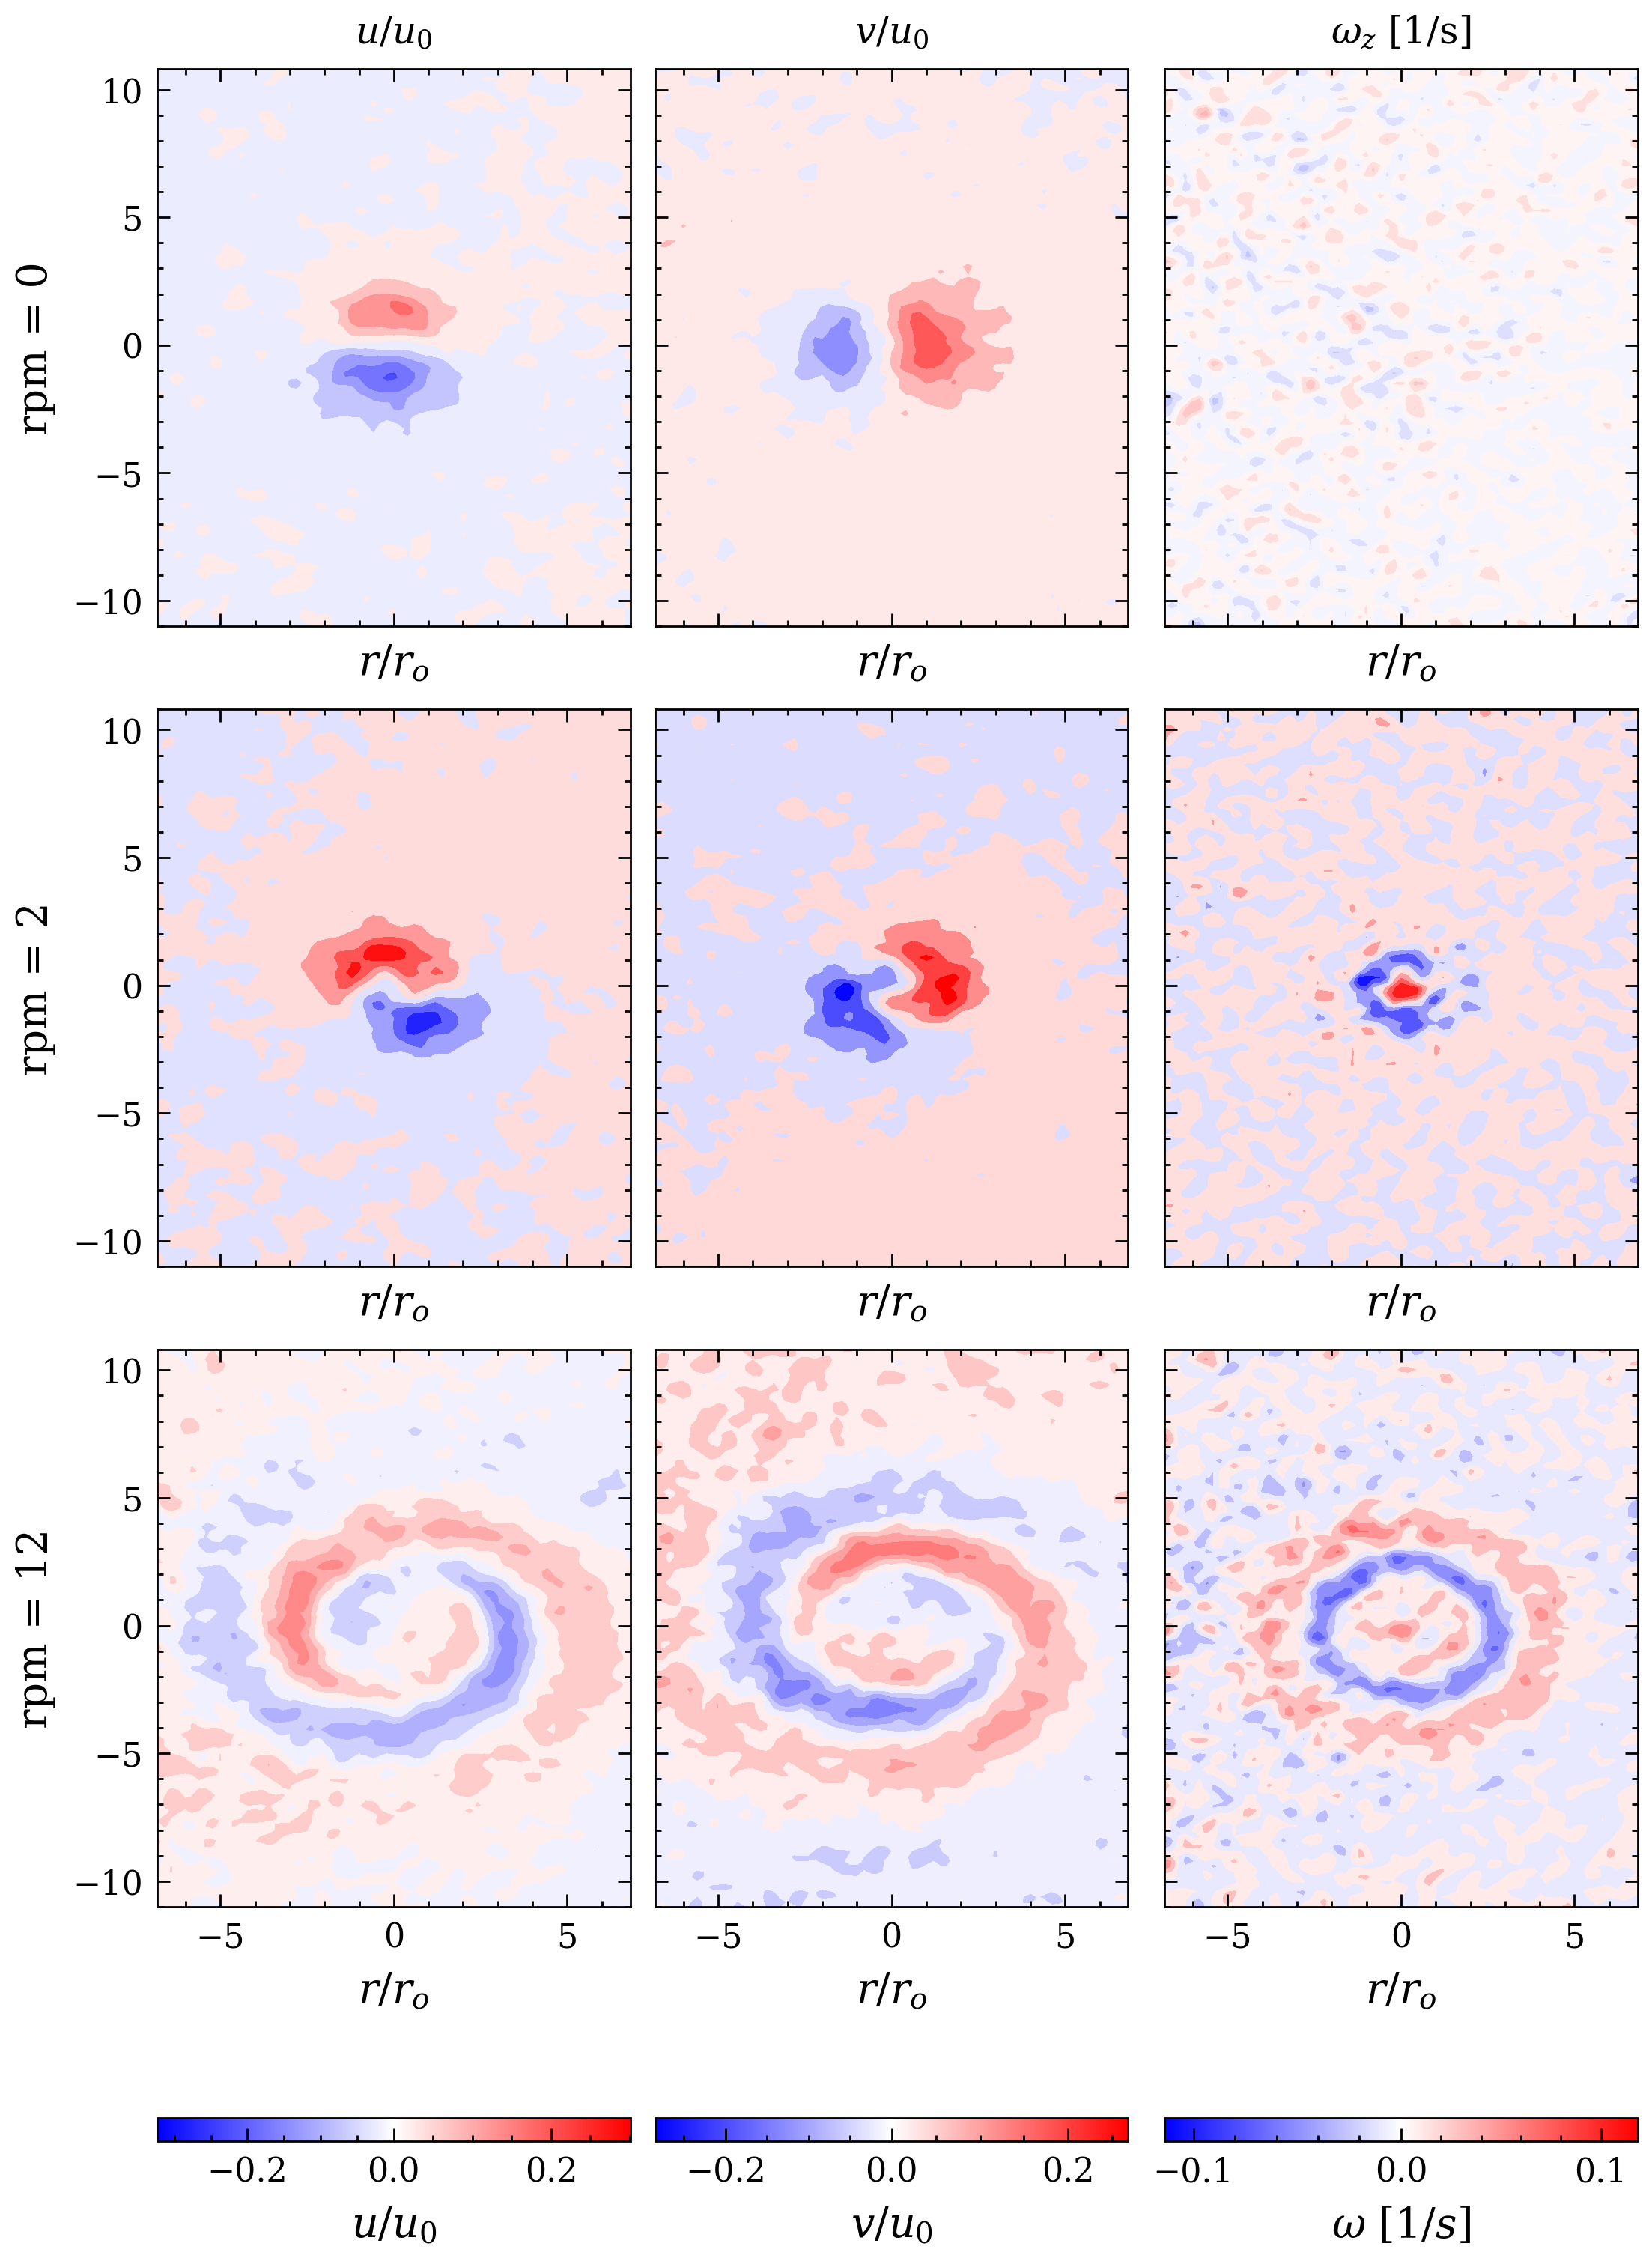

In [38]:
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
index = 0
rpms = [0, 2, 12]
Eks = [0.0000102, 0.0000051, 0.0000034]

frame = 1080
frames0 = [750, 1020, 1470]
frames2 = [840, 1125, 2295]
frames3 = [750, 1080, 2295]

vels = h5file['3D0']['U100']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])

u = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
v = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
vort = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))
vortGauss = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))


for i in range(3):
    vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[i])}']
    # vels = h5file['3D0']['U100']['L100'][f'RPM0']
    u[:,:,:,i] = vels[:,:,:,0]
    v[:,:,:,i] = vels[:,:,:,1]
    u[:,:,:,i], v[:,:,:,i] = oj.scaleVel(u[:,:,:,i], v[:,:,:,i], 60) #make sure to change this for the wide fov data
    u[:,:,:,i], v[:,:,:,i] = u[:,:,:,i]*25, v[:,:,:,i]*25
    vort[:,:,:,i], vortGauss[:,:,:,i] = oj.calculate_vorticity(u[:,:,:,i], v[:,:,:,i])


umin = np.min(u[frame,:,:,:])
umax = np.max(u[frame,:,:,:])
unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

vmin = np.min(v[frame,:,:,:])
vmax = np.max(v[frame,:,:,:])
vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

omin = np.min(vort[frame,:,:,:])
omax = np.max(vort[frame,:,:,:])
onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)


fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):
    ax[0, 0].set_title(r'$u/u_{0}$', fontsize=9)
    ax[0, 1].set_title(r'$v/u_{0}$', fontsize=9)
    ax[0, 2].set_title(r'$\omega_{z}$ [1/s]', fontsize=9)

    ax[i, 0].contourf(r_nd, -z_nd, np.rot90(u   [frame,:,:,i],3), cmap = 'bwr', norm = unorm)
    ax[i, 0].set_xlabel(r"$r/r_{o}$")
    ax[i, 0].set_ylabel(rf"rpm = {rpms[i]}")
    ax[i, 1].contourf(r_nd, -z_nd, np.rot90(v   [frame,:,:,i],3), cmap = 'bwr', norm = vnorm)
    ax[i, 1].set_xlabel(r"$r/r_{o}$")
    ax[i, 2].contourf(r_nd, -z_nd, np.rot90(vort[frame,:,:,i],3), cmap = 'bwr', norm = onorm)
    ax[i, 2].set_xlabel(r"$r/r_{o}$")

fig.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=ax[:,0], label=r'$u/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=ax[:,1], label=r'$v/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=ax[:,2], label=r'$\omega ~[1/s]$', location='bottom')

3 time steps for radial flow
3 time steps for azimuthal flow

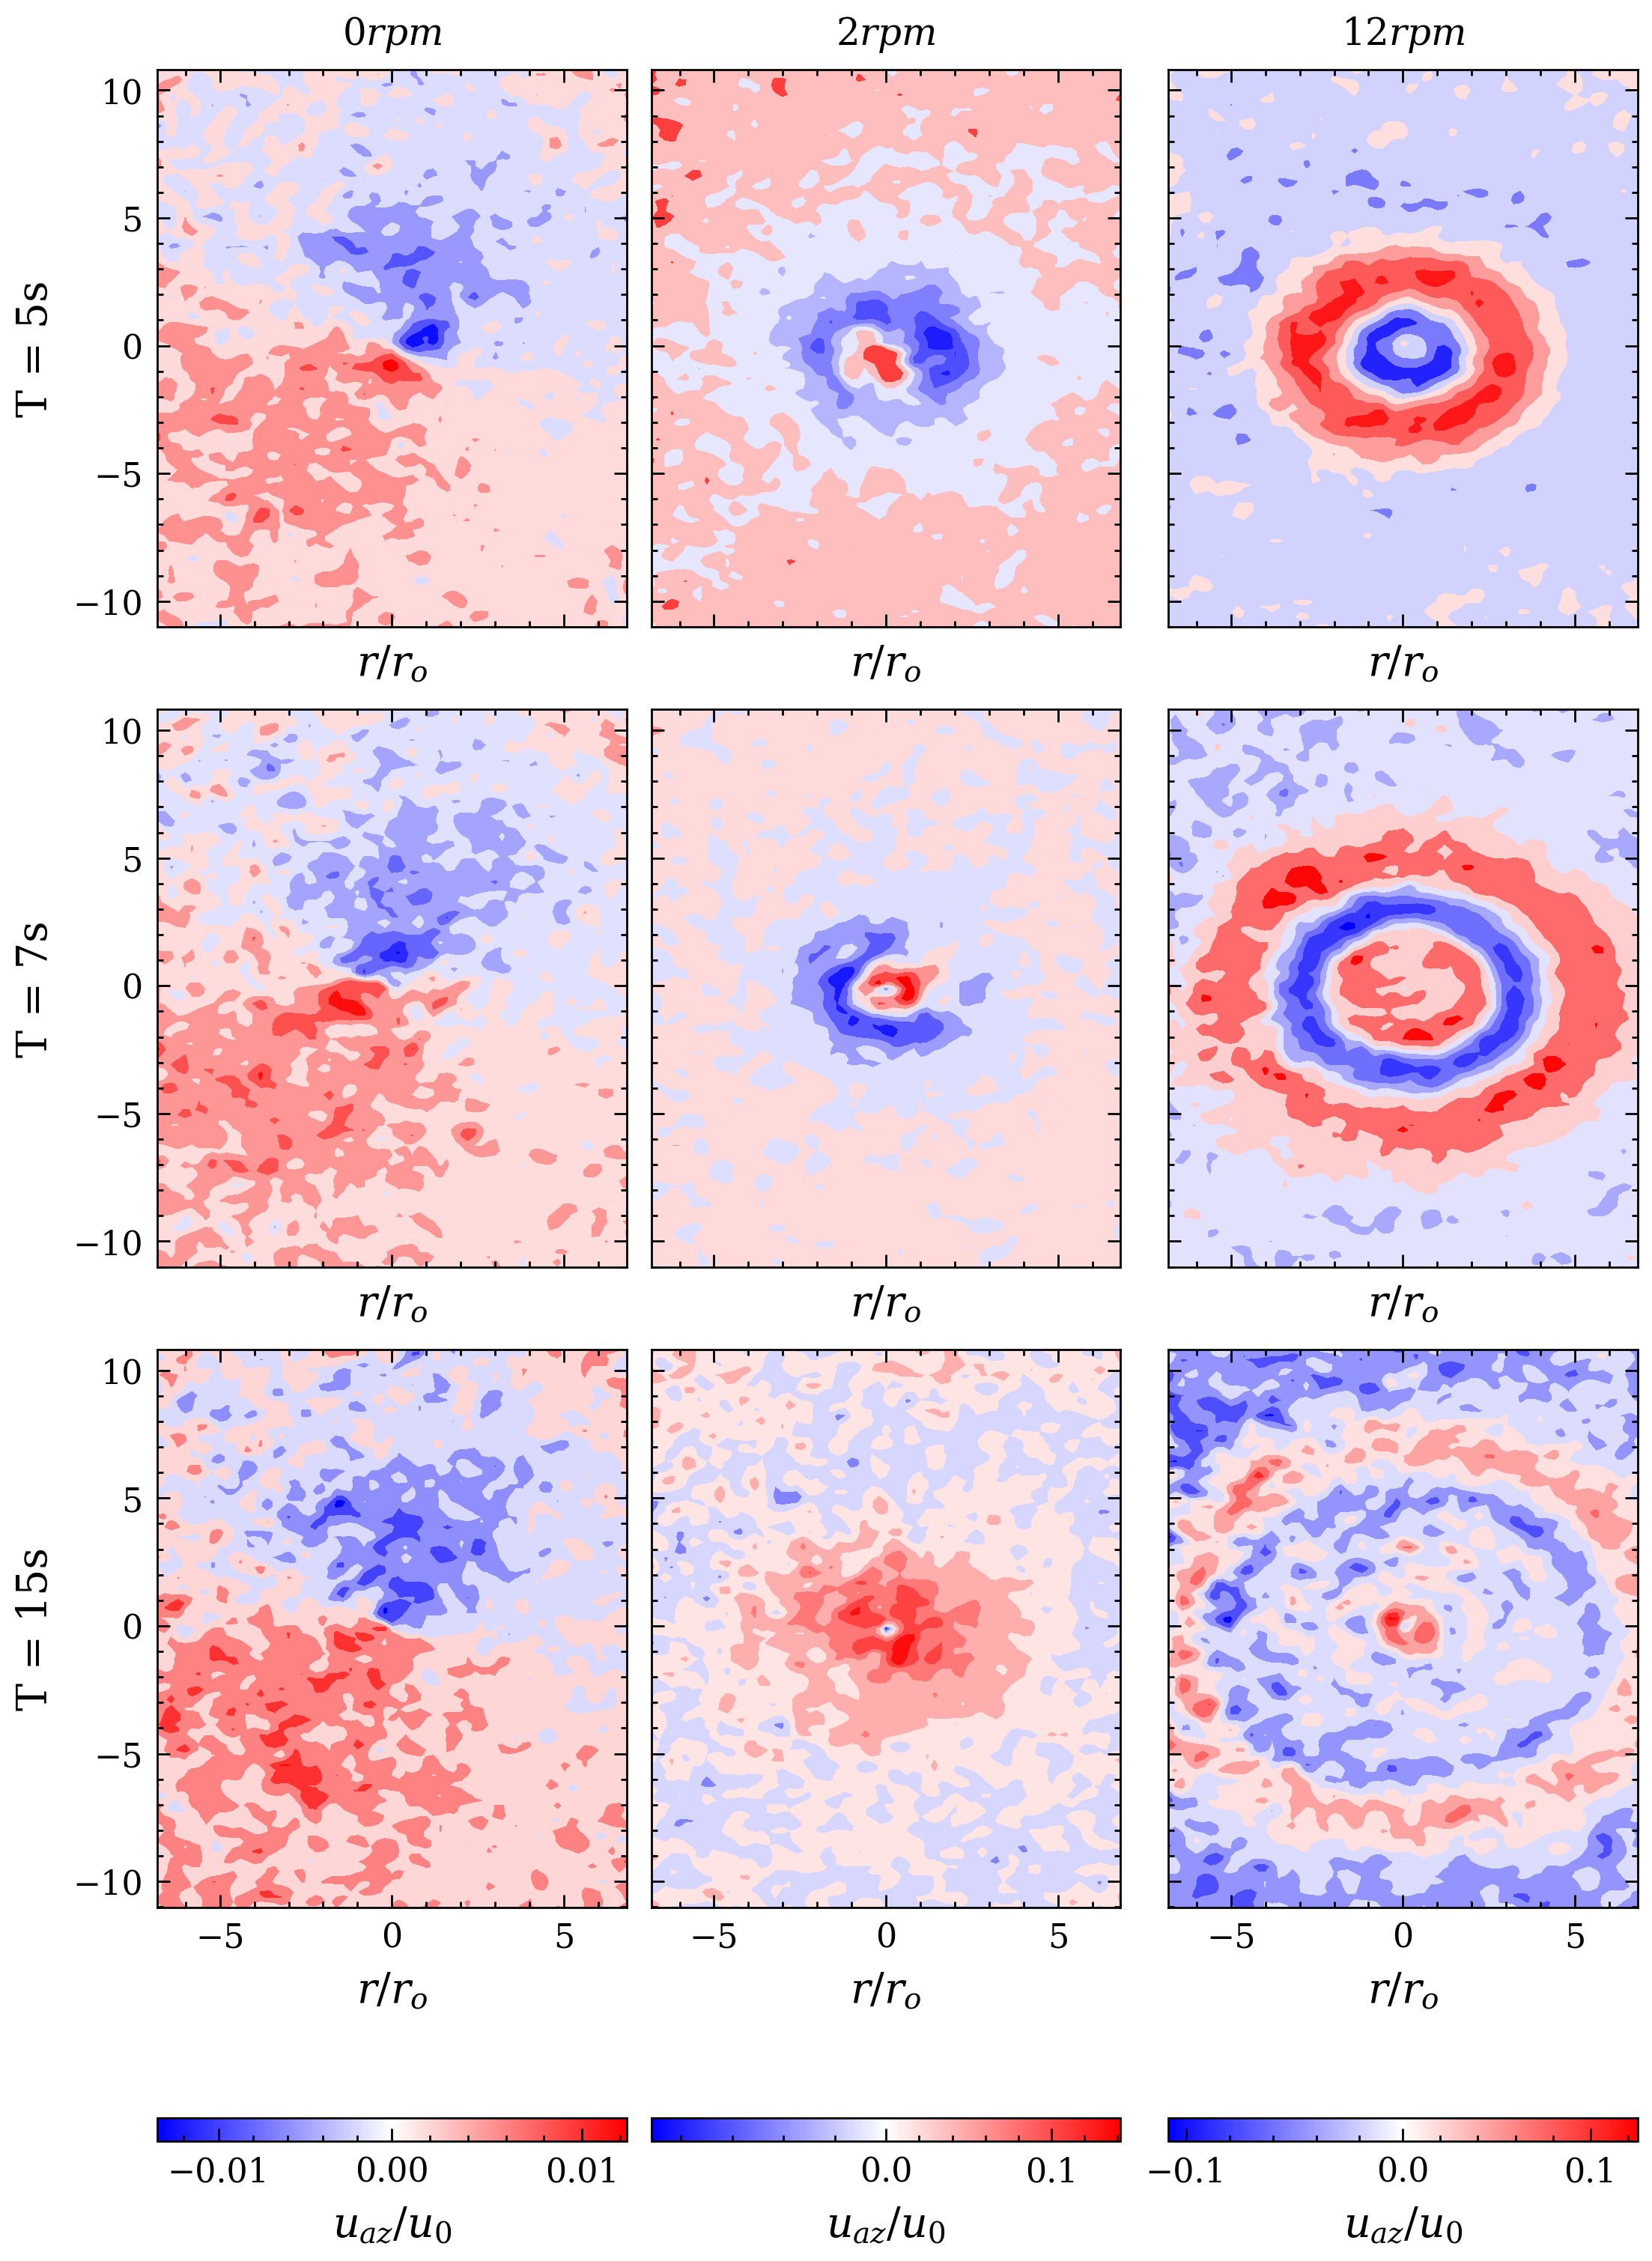

In [48]:
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
index = 0
rpms = [0, 2, 12]

times = [5, 7, 15]
frames0 = [750, 1020, 1470]
frames2 = [840, 1125, 2295]
frames12 = [750, 1080, 2295]

vels = h5file['3D0']['U100']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])
r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(55, 35, x, y, u[1500,:,:], v[1500,:,:])

u = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
v = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
vort = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))
vortGauss = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))


for i in range(3):
    vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[i])}']
    # vels = h5file['3D0']['U100']['L100'][f'RPM0']
    u[:,:,:,i] = vels[:,:,:,0]
    v[:,:,:,i] = vels[:,:,:,1]
    # u[:,:,:,i], v[:,:,:,i] = oj.scaleVel(u[:,:,:,i], v[:,:,:,i], 150) #make sure to change this for the wide fov data
    # u[:,:,:,i], v[:,:,:,i] = u[:,:,:,i]*25, v[:,:,:,i]*25
    # vort[:,:,:,i], vortGauss[:,:,:,i] = oj.calculate_vorticity(u[:,:,:,i], v[:,:,:,i])


# umin = np.min(u[frame,:,:,:])
# umax = np.max(u[frame,:,:,:])
# unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

# vmin = np.min(v[frame,:,:,:])
# vmax = np.max(v[frame,:,:,:])
# vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# omin = np.min(vort[frame,:,:,:])
# omax = np.max(vort[frame,:,:,:])
# onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)


fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):

    _,_,U_r0, U_az0,_,_   = oj.ConvertCylindrical(55, 35, x, y, u[frames0 [i],:,:,0], v[frames0 [i],:,:,0])
    _,_,U_r2, U_az2,_,_   = oj.ConvertCylindrical(55, 35, x, y, u[frames2 [i],:,:,1], v[frames2 [i],:,:,1])
    _,_,U_r12, U_az12,_,_ = oj.ConvertCylindrical(55, 35, x, y, u[frames12[i],:,:,2], v[frames12[i],:,:,2])

    min0 = np.min(U_az0[:,:]*0.2)
    max0 = np.max(U_az0[:,:]*0.2)
    norm0 = colors.TwoSlopeNorm(vmin=min0, vcenter=0, vmax=max0)


    min2 = np.min(U_az2[:,:])
    max2 = np.max(U_az2[:,:])
    norm2 = colors.TwoSlopeNorm(vmin=min2, vcenter=0, vmax=max2)

    min12 = np.min(U_az12[:,:])
    max12 = np.max(U_az12[:,:])
    norm12 = colors.TwoSlopeNorm(vmin=min12, vcenter=0, vmax=max12)

    ax[0, 0].set_title(r'$0rpm$', fontsize=9)
    ax[0, 1].set_title(r'$2rpm$', fontsize=9)
    ax[0, 2].set_title(r'$12rpm$', fontsize=9)

    ax[i, 0].contourf(r_nd, -z_nd, np.rot90(U_az0   [:,:,]*0.2,3), cmap = 'bwr', norm = norm0)
    ax[i, 0].set_xlabel(r"$r/r_{o}$")
    ax[i, 0].set_ylabel(rf"T = {times[i]}s")
    ax[i, 1].contourf(r_nd, -z_nd, np.rot90(U_az2   [:,:,],3), cmap = 'bwr', norm = norm2)
    ax[i, 1].set_xlabel(r"$r/r_{o}$")
    ax[i, 2].contourf(r_nd, -z_nd, np.rot90(U_az12   [:,:,],3), cmap = 'bwr', norm = norm12)
    ax[i, 2].set_xlabel(r"$r/r_{o}$")




fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm0, cmap='bwr'), ax=ax[:,0], label=r'$u_{az}/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm2, cmap='bwr'), ax=ax[:,1], label=r'$u_{az}/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm12, cmap='bwr'), ax=ax[:,2], label=r'$u_{az}/u_{0}$', location='bottom')

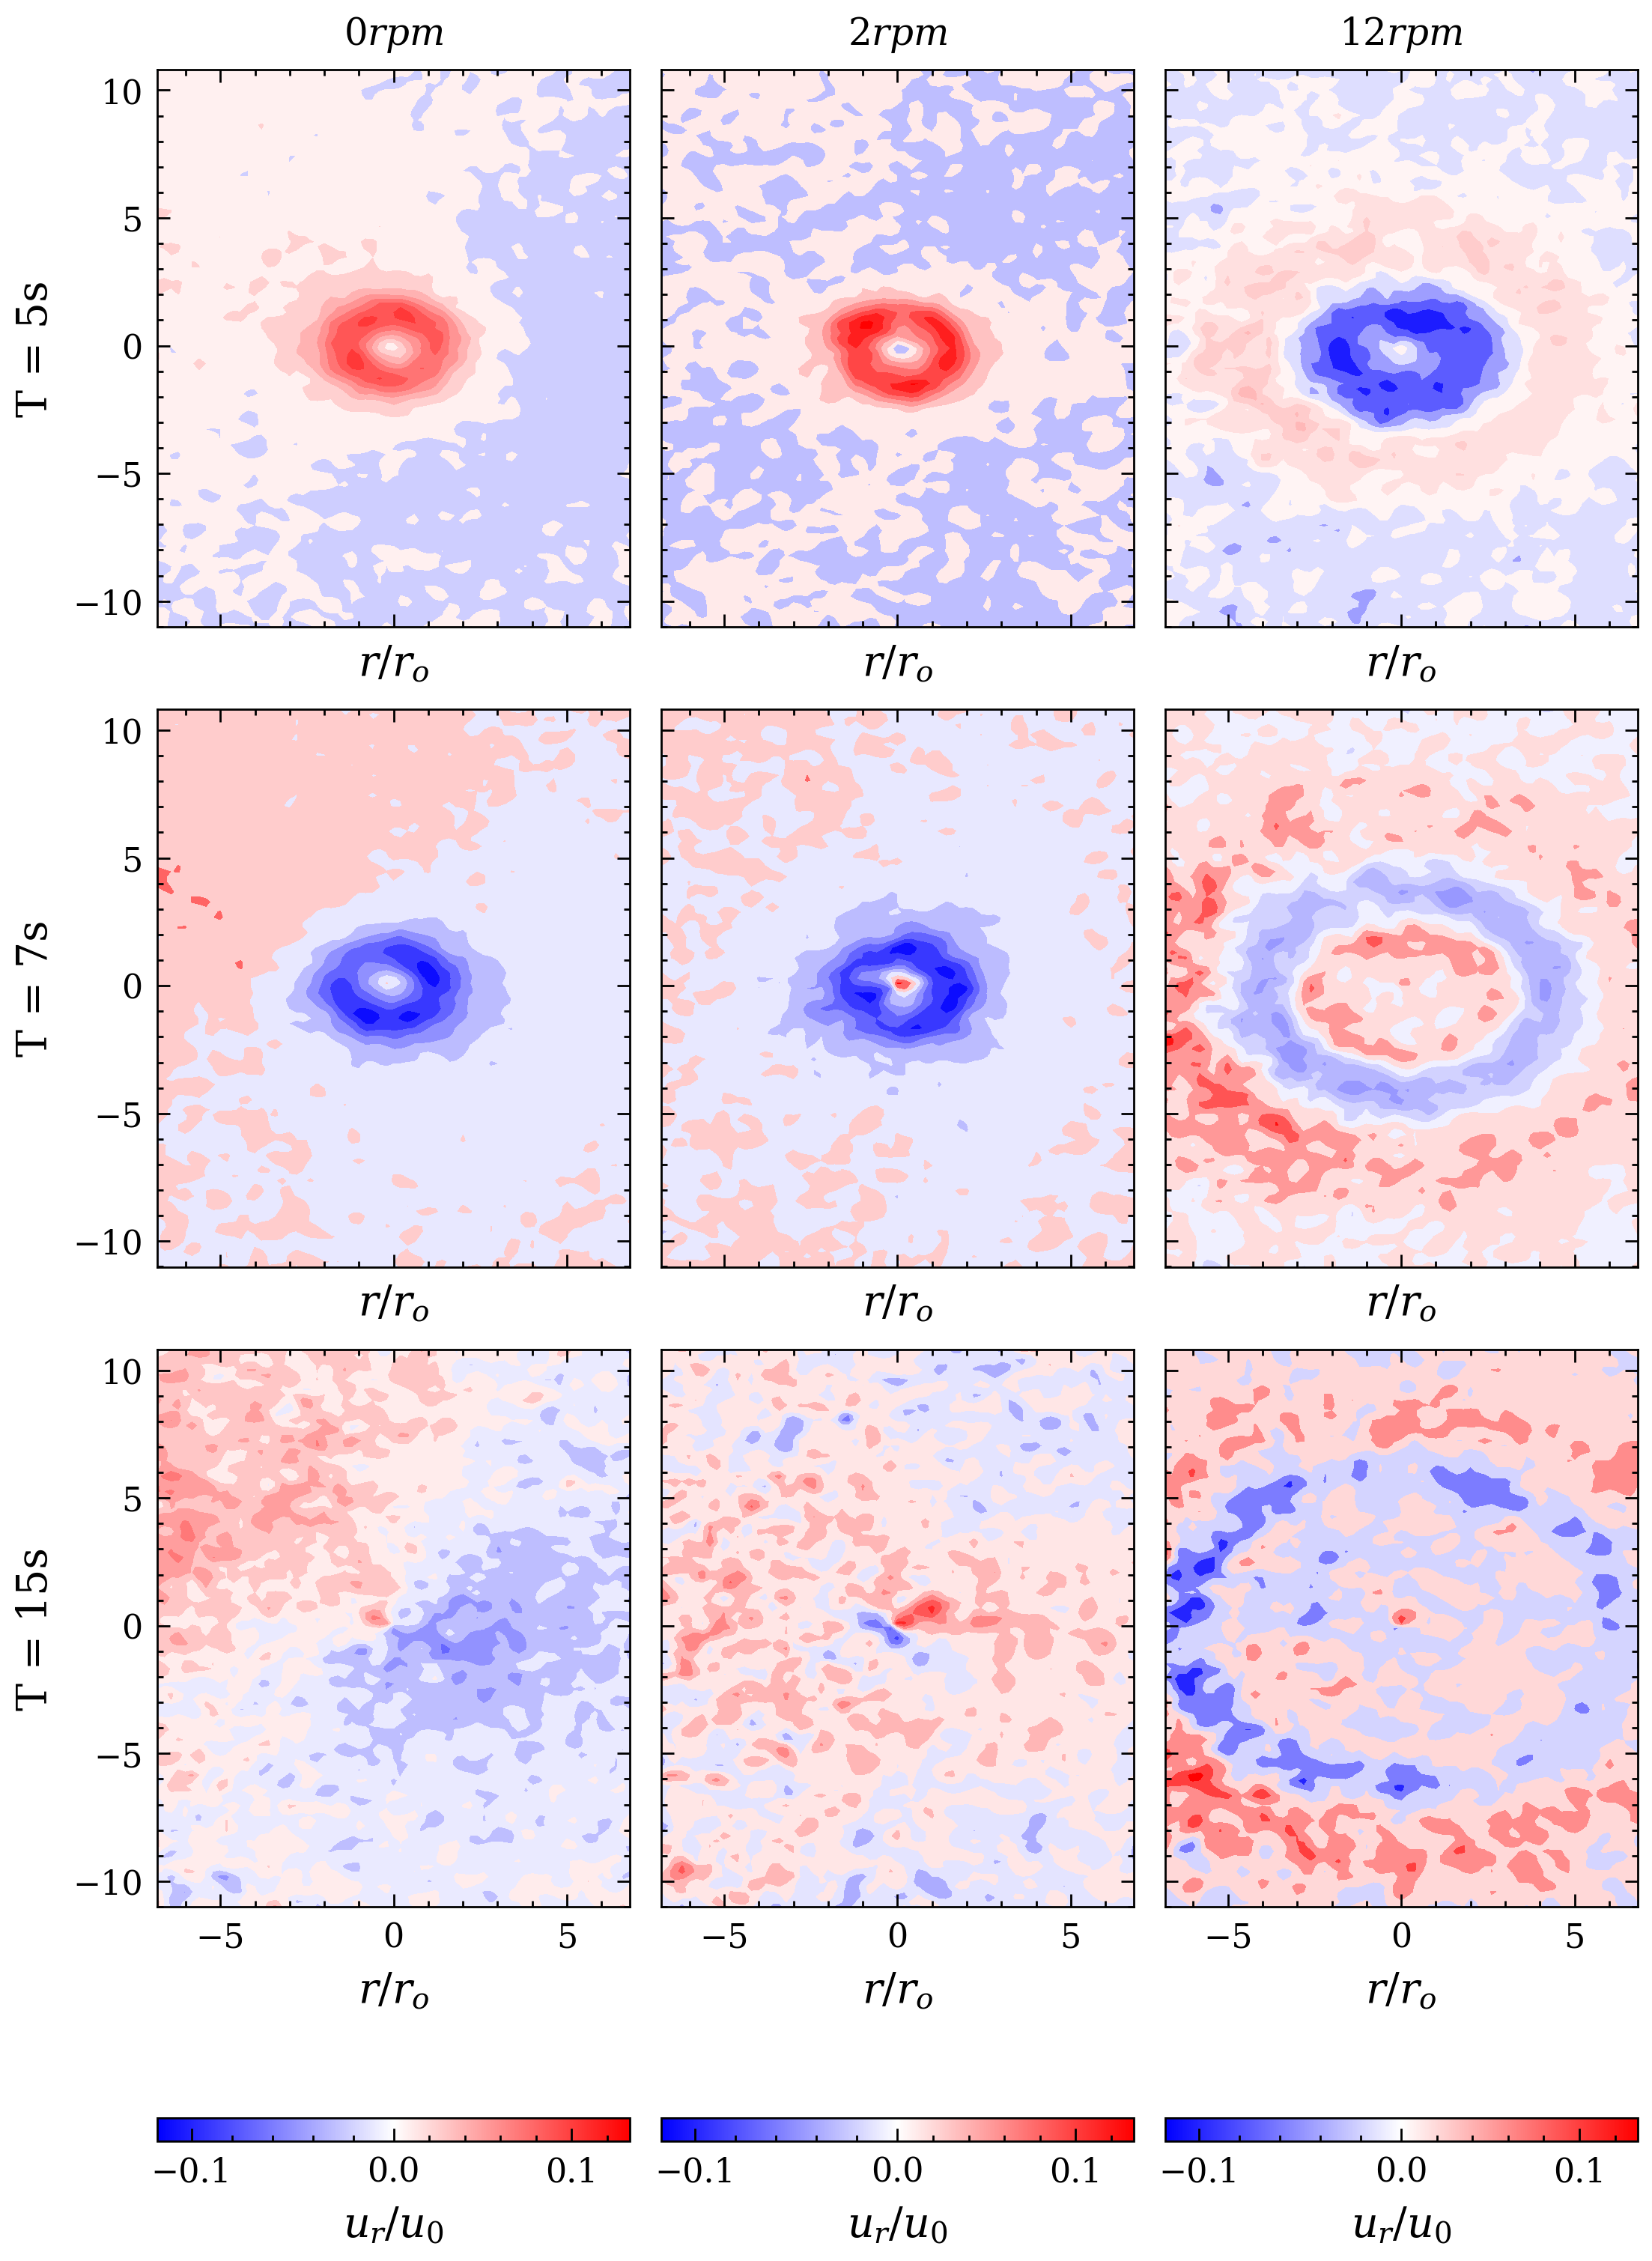

In [51]:
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
index = 0
rpms = [0, 2, 12]

times = [5, 7, 15]
frames0 = [750, 1020, 1470]
frames2 = [840, 1125, 2295]
frames12 = [750, 1080, 2295]

vels = h5file['3D0']['U100']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])
r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(55, 35, x, y, u[1500,:,:], v[1500,:,:])

u = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
v = np.zeros((u.shape[0], u.shape[1], u.shape[2],3))
vort = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))
vortGauss = np.zeros((u.shape[0], u.shape[1], u.shape[2], 3))


for i in range(3):
    vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[i])}']
    # vels = h5file['3D0']['U100']['L100'][f'RPM0']
    u[:,:,:,i] = vels[:,:,:,0]
    v[:,:,:,i] = vels[:,:,:,1]
    # u[:,:,:,i], v[:,:,:,i] = oj.scaleVel(u[:,:,:,i], v[:,:,:,i], 150) #make sure to change this for the wide fov data
    # u[:,:,:,i], v[:,:,:,i] = u[:,:,:,i]*25, v[:,:,:,i]*25
    # vort[:,:,:,i], vortGauss[:,:,:,i] = oj.calculate_vorticity(u[:,:,:,i], v[:,:,:,i])


# umin = np.min(u[frame,:,:,:])
# umax = np.max(u[frame,:,:,:])
# unorm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax)

# vmin = np.min(v[frame,:,:,:])
# vmax = np.max(v[frame,:,:,:])
# vnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# omin = np.min(vort[frame,:,:,:])
# omax = np.max(vort[frame,:,:,:])
# onorm = colors.TwoSlopeNorm(vmin=omin, vcenter=0, vmax=omax)


fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5.5, 7.5), dpi = 400)
for i in range(3):

    _,_,U_r0, U_az0,_,_   = oj.ConvertCylindrical(55, 35, x, y, u[frames0 [i],:,:,0], v[frames0 [i],:,:,0])
    _,_,U_r2, U_az2,_,_   = oj.ConvertCylindrical(55, 35, x, y, u[frames2 [i],:,:,1], v[frames2 [i],:,:,1])
    _,_,U_r12, U_az12,_,_ = oj.ConvertCylindrical(55, 35, x, y, u[frames12[i],:,:,2], v[frames12[i],:,:,2])

    min0 = np.min(U_r0[:,:])
    max0 = np.max(U_r0[:,:])
    norm0 = colors.TwoSlopeNorm(vmin=min0, vcenter=0, vmax=max0)


    min2 = np.min(U_r2[:,:])
    max2 = np.max(U_r2[:,:])
    norm2 = colors.TwoSlopeNorm(vmin=min2, vcenter=0, vmax=max2)

    min12 = np.min(U_r12[:,:])
    max12 = np.max(U_r12[:,:])
    norm12 = colors.TwoSlopeNorm(vmin=min12, vcenter=0, vmax=max12)

    umin = np.min([np.min(U_r0[:,:]), np.min(U_r2[:,:]), np.min(U_r12[:,:])])
    umax = np.max([np.max(U_r0[:,:]), np.max(U_r2[:,:]), np.max(U_r12[:,:])])
    norm = colors.TwoSlopeNorm(vmin=umin, vcenter=0, vmax=umax) 

    ax[0, 0].set_title(r'$0rpm$', fontsize=9)
    ax[0, 1].set_title(r'$2rpm$', fontsize=9)
    ax[0, 2].set_title(r'$12rpm$', fontsize=9)

    ax[i, 0].contourf(r_nd, -z_nd, np.rot90(U_r0   [:,:,],3), cmap = 'bwr', norm = norm)
    ax[i, 0].set_xlabel(r"$r/r_{o}$")
    ax[i, 0].set_ylabel(rf"T = {times[i]}s")
    ax[i, 1].contourf(r_nd, -z_nd, np.rot90(U_r2   [:,:,],3), cmap = 'bwr', norm = norm)
    ax[i, 1].set_xlabel(r"$r/r_{o}$")
    ax[i, 2].contourf(r_nd, -z_nd, np.rot90(U_r12   [:,:,],3), cmap = 'bwr', norm = norm)
    ax[i, 2].set_xlabel(r"$r/r_{o}$")




fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax[:,0], label=r'$u_{r}/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax[:,1], label=r'$u_{r}/u_{0}$', location='bottom')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax[:,2], label=r'$u_{r}/u_{0}$', location='bottom')